In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [67]:
dataset = "advertising_sales_data.xlsx"
df = pd.read_excel(dataset)


In [68]:
x = df.iloc[:,1:-1].values
y = df.iloc[:,-1]

In [69]:
import numpy as np
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(x[:, [1]])
x[:, [1]] = imputer.transform(x[:, [1]])
print(x)


[[230.1         37.8         69.2       ]
 [ 44.5         39.3         45.1       ]
 [ 17.2         45.9         69.3       ]
 [151.5         41.3         58.5       ]
 [180.8         10.8         58.4       ]
 [  8.7         48.9         75.        ]
 [ 57.5         32.8         23.5       ]
 [120.2         19.6         11.6       ]
 [  8.6          2.1          1.        ]
 [199.8          2.6         21.2       ]
 [ 66.1          5.8         24.2       ]
 [214.7         24.           4.        ]
 [ 23.8         35.1         65.9       ]
 [ 97.5          7.6          7.2       ]
 [204.1         32.9         46.        ]
 [195.4         47.7         52.9       ]
 [ 67.8         36.6        114.        ]
 [281.4         39.6         55.8       ]
 [ 69.2         20.5         18.3       ]
 [147.3         23.26060606  19.1       ]
 [218.4         27.7         53.4       ]
 [237.4          5.1         23.5       ]
 [ 13.2         15.9         49.6       ]
 [228.3         16.9         26.2 

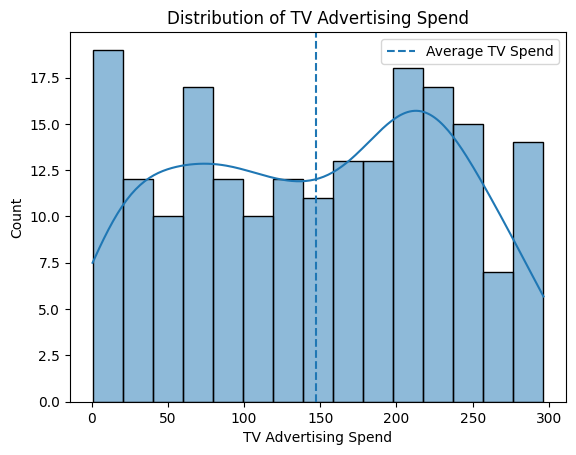


Average TV Advertising Spend: 147.0425


In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["TV"], bins=15, kde=True)

plt.axvline(df["TV"].mean(), linestyle="--", label="Average TV Spend")

plt.xlabel("TV Advertising Spend")
plt.title("Distribution of TV Advertising Spend")

plt.legend()
plt.show()

print("\nAverage TV Advertising Spend:", avg_tv)

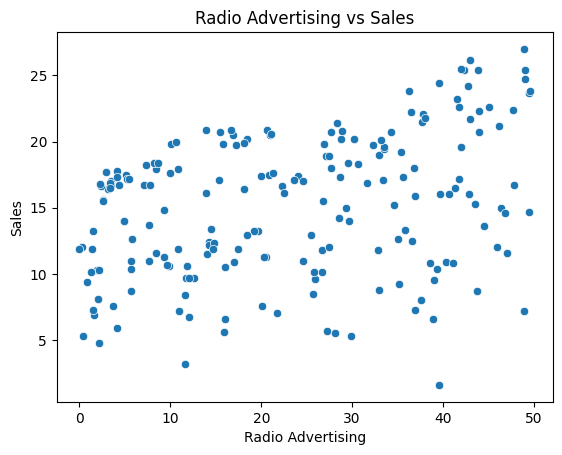


Correlation: 0.3497277129207837


In [71]:
import seaborn as sns

sns.scatterplot(x=df["Radio"], y=df["Sales"])

plt.xlabel("Radio Advertising")
plt.ylabel("Sales")
plt.title("Radio Advertising vs Sales")

plt.show()

print("\nCorrelation:", df["Radio"].corr(df["Sales"]))

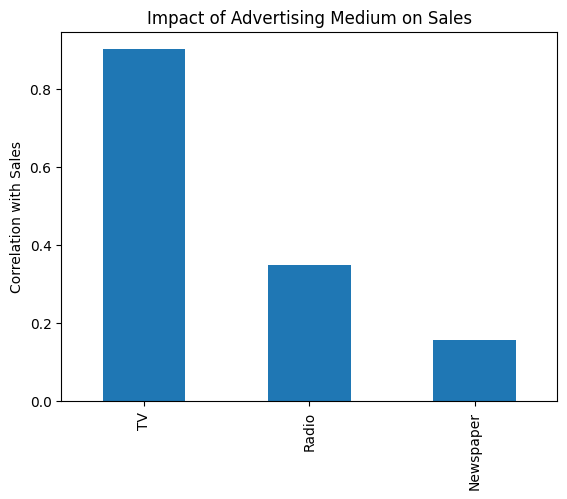

In [72]:
corr = df[["TV","Radio","Newspaper","Sales"]].corr()

corr["Sales"][:-1].plot(kind="bar")

plt.title("Impact of Advertising Medium on Sales")
plt.ylabel("Correlation with Sales")

plt.show()

In [73]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [74]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

y_pred=lr.predict(x_test)


In [75]:
result = pd.DataFrame({"Actual": y_test,"Predicted": y_pred})

print(result.head())

     Actual  Predicted
95     16.9  17.034976
15     22.4  20.410280
30     21.4  23.724247
158     7.3   9.273273
128    24.7  21.684108


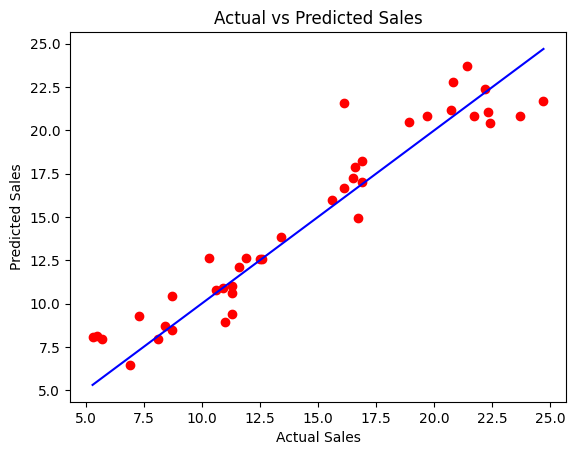

In [76]:
plt.scatter(y_test, y_pred, color='red', label='Testing Data')

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color='blue', linestyle='-', label='Prediction Line'
    )

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [77]:
new_data = [[200,40,50]]
prediction = lr.predict(new_data)

print(prediction)

[19.87104921]


In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

sc = StandardScaler()

x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

lr_scaled = LinearRegression()
lr_scaled.fit(x_train_scaled, y_train)

y_pred_scaled = lr_scaled.predict(x_test_scaled)

print("R2 without scaling:", r2_score(y_test,y_pred))
print("R2 with scaling:", r2_score(y_test,y_pred_scaled))

R2 without scaling: 0.9059117026092904
R2 with scaling: 0.9059117026092904


In [81]:
x2 = df[["Radio","Newspaper"]].values
from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(strategy="mean")
x2 = df[["Radio","Newspaper"]].values
x2 = imputer.fit_transform(x2)
x_train2,x_test2,y_train2,y_test2 = train_test_split(x2,y,test_size=0.2,random_state=42)

lr2 = LinearRegression()
lr2.fit(x_train2,y_train2)

y_pred2 = lr2.predict(x_test2)

print("R2 Score:", r2_score(y_test2,y_pred2))

R2 Score: 0.10998637077378093
